<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_gab_v11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏧 Détection d'Anomalies sur le Réseau GAB — Analyse Journalière
## Identification automatique des comportements atypiques sur les Guichets Automatiques Bancaires

---

> **Destinataires :** Experts métier – Responsables réseau GAB
> **Objectif :** Identifier automatiquement les GAB au comportement inhabituel, sans étiquette préalable
> **Approche :** Détection d'anomalies non supervisée (Isolation Forest) + Clustering comportemental (K-Means / Agglomératif / Gaussian Mixture)
> **Maille d'analyse :** **Journalière** (1 ligne = 1 GAB × 1 jour), avec agrégation multi-échelle semaine → mois → année

---

## Ce qui change par rapport à la version précédente (mensuelle)

La version précédente de ce notebook analysait le comportement des GAB à la **maille mensuelle** : 1 ligne = 1 GAB × 1 mois. Cette approche a une limite structurelle : **un GAB peut présenter un comportement anormal sur une seule journée** (incident technique, fraude ponctuelle, panne) **sans que cela soit visible une fois moyenné sur 30 jours**. L'anomalie se noie dans la moyenne mensuelle.

Le système source (`fiche_identite_gab`) est désormais alimenté à la **maille journalière**. Cette évolution permet de :

1. Analyser le comportement quotidien de chaque GAB.
2. Détecter les journées atypiques, même isolées.
3. Comparer ces comportements sur plusieurs échelles temporelles (semaine, mois, année).
4. Distinguer les **anomalies ponctuelles** (un incident isolé, 1 à 3 jours) des **comportements durablement atypiques** (une dérive qui s'installe sur plusieurs semaines).
5. Construire des **familles comportementales stables** (clustering) mieux séparées qu'avant, en corrigeant les faiblesses méthodologiques identifiées dans la version précédente (features redondantes, nombre de familles imposé arbitrairement).

## Pourquoi surveiller le comportement des GAB ?

Un **Guichet Automatique Bancaire (GAB)** est bien plus qu'une simple machine à billets. Chaque jour, il enregistre des dizaines d'opérations : retraits, refus, captures de carte… L'ensemble de ces comportements forme une **empreinte quotidienne** propre à chaque automate.

**Un GAB "normal"** présente, jour après jour, un volume de retraits stable compte tenu de son emplacement, un taux de capture de carte faible, une activité concentrée sur les horaires d'ouverture commerçants, et une répartition de réseaux de cartes cohérente avec sa zone géographique.

**Un GAB atypique** peut au contraire connaître un pic ou un creux d'activité brutal et isolé (panne, incident), une dérive progressive sur plusieurs semaines (dégradation matérielle, changement d'environnement), ou une divergence durable par rapport aux autres GAB de profil comparable.


## 1. ⚙️ Imports et Configuration

Ce notebook est conçu pour tourner sous **Dataiku DSS**, kernel Python 3.6, avec les versions suivantes (vérifiées en environnement de production) : **pandas 1.1.5** et **scikit-learn 0.21.1**.

⚠️ Toutes les fonctions utilisées ci-dessous sont disponibles nativement à ces versions. En particulier :
- Pas de `HDBSCAN` natif (introduit en scikit-learn 1.3, 2023) → nous comparons `KMeans`, `AgglomerativeClustering` et `GaussianMixture`, tous disponibles depuis longtemps.
- Pas de paramètre `sparse_output=` sur `OneHotEncoder` (introduit en 1.2) → non utilisé ici, nous n'avons pas besoin d'encodage one-hot dans ce pipeline.
- `IsolationForest`, `silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score` sont stables depuis scikit-learn 0.20-0.21.


In [1]:
# ── Librairies ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# ── Configuration graphique ───────────────────────────────────────────────────
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['axes.facecolor']    = 'white'
sns.set_style('whitegrid')

COULEUR_NORMAL    = '#2E7D32'   # vert
COULEUR_PONCTUEL  = '#F9A825'   # orange
COULEUR_RECURRENT = '#C62828'   # rouge
COULEUR_ANOMALIE  = '#C62828'

RNG_SEED = 42
np.random.seed(RNG_SEED)

print('✅ Environnement chargé — pandas', pd.__version__)
import sklearn
print('✅ scikit-learn', sklearn.__version__)


✅ Environnement chargé — pandas 2.2.3
✅ scikit-learn 1.7.2


## 2. 🏗️ Génération du Dataset Journalier Synthétique

⚠️ **Aucune donnée bancaire réelle n'est utilisée.** Pour des raisons de confidentialité, nous générons un dataset **fictif mais statistiquement réaliste**, à la maille **1 ligne = 1 GAB × 1 jour calendaire**, sur la période **2024-01-01 → 2026-06-30** (~912 jours), pour ~120 GAB en **France métropolitaine uniquement**.

Ce générateur reproduit la structure de la table réelle `fiche_identite_gab` (voir `fiche_identite_gab_final.hql`), adaptée de la maille mensuelle à la maille journalière : mêmes flags (`is_weekend`, horaires de nuit/heure de pointe), mêmes agrégats de retraits/captures/réseaux — mais recalculés chaque jour au lieu de chaque mois.

### Trois régimes comportementaux distincts injectés

Pour que ce notebook ait un signal réaliste à détecter à **chaque échelle temporelle**, trois régimes indépendants sont assignés aux GAB :

| Régime | % des GAB | Description |
|---|---|---|
| 🟢 **STABLE** | 80% | Comportement normal, avec une **famille structurelle légitime** (urbain dense, urbain standard, touristique) qui influence son profil de façon permanente — ce n'est **pas** une anomalie, c'est un profil différent. |
| 🟡 **PONCTUEL** | 10% | 2 à 4 incidents isolés de 1 à 3 jours sur toute la période (ex. panne ponctuelle, pic de captures un jour donné). |
| 🔴 **RÉCURRENT** | 10% | 1 à 2 fenêtres de dérive continue de 4 à 10 semaines (ex. dégradation progressive, changement d'environnement). |

Cette distinction est **cruciale** : dans la version précédente du notebook, les mêmes "profils d'anomalie" servaient à la fois à définir le flag SQL et le nom du cluster K-Means, ce qui mélangeait deux concepts différents. Ici, le **régime d'anomalie** (ponctuel/récurrent/stable) et la **famille structurelle** (type de zone géographique) sont deux dimensions indépendantes.

Un label caché (`anomalie_synthetique_type`, `anomalie_synthetique_regime_gab`) trace ces injections. **Il ne sera utilisé que dans une section de validation pédagogique dédiée (section 8bis)**, jamais dans le feature engineering ni la modélisation — exactement comme en production où ce label n'existe pas.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Génération du dataset journalier — Métropole uniquement, 2024-2025-2026
# ══════════════════════════════════════════════════════════════════════════════
#
# En production Dataiku (décommenter) :
# import dataiku
# df = dataiku.Dataset('fiche_identite_gab_journalier').get_dataframe()

np.random.seed(RNG_SEED)

N_GAB = 120
DATES = pd.date_range('2024-01-01', '2026-06-30', freq='D')
N_JOURS = len(DATES)

# ── Contextes géographiques — Métropole uniquement ───────────────────────────
CONTEXTES_GEO = {
    '75001': {'lat': 48.860, 'lon':  2.347, 'base': 32, 'sig': 5.0, 'type': 'urbain_dense'},
    '69001': {'lat': 45.764, 'lon':  4.835, 'base': 24, 'sig': 4.0, 'type': 'urbain_dense'},
    '13001': {'lat': 43.297, 'lon':  5.381, 'base': 26, 'sig': 4.2, 'type': 'touristique'},
    '33000': {'lat': 44.837, 'lon': -0.579, 'base': 22, 'sig': 3.6, 'type': 'urbain_standard'},
    '59000': {'lat': 50.629, 'lon':  3.057, 'base': 20, 'sig': 3.4, 'type': 'urbain_standard'},
    '06000': {'lat': 43.710, 'lon':  7.262, 'base': 28, 'sig': 4.4, 'type': 'touristique'},
}
CPS  = list(CONTEXTES_GEO.keys())
PROB = [0.22, 0.16, 0.15, 0.15, 0.13, 0.19]

# ── Saisonnalités ─────────────────────────────────────────────────────────────
SAISON_DOW  = np.array([0.85, 0.90, 0.92, 0.95, 1.15, 1.30, 0.55])  # lundi..dimanche
SAISON_MOIS = {1:.90,2:.88,3:.93,4:.96,5:.98,6:1.05,7:1.13,8:1.16,9:1.01,10:.97,11:.95,12:1.19}

def jours_feries(annee):
    fixes = [(1,1),(5,1),(5,8),(7,14),(8,15),(11,1),(11,11),(12,25)]
    return [pd.Timestamp(annee, m, d) for m, d in fixes]

FERIES = set()
for a in [2024, 2025, 2026]:
    FERIES |= set(jours_feries(a))
FERIE_MULT = 0.35

dow       = DATES.dayofweek.values
mois_arr  = DATES.month.values
annee_arr = DATES.year.values
is_ferie  = np.array([d in FERIES for d in DATES])
saison_globale = SAISON_DOW[dow] * np.array([SAISON_MOIS[m] for m in mois_arr]) * np.where(is_ferie, FERIE_MULT, 1.0)

SAISON_JCB  = np.array([SAISON_MOIS[m] for m in mois_arr]) * np.where(np.isin(mois_arr,[7,8]), 2.3, 1.0)
SAISON_AMEX = np.array([SAISON_MOIS[m] for m in mois_arr]) * np.where(np.isin(mois_arr,[7,8]), 1.8, 1.0)

gab_ids    = [f'GAB_{i:04d}' for i in range(N_GAB)]
cp_assign  = np.random.choice(CPS, size=N_GAB, p=PROB)
regime_gab = np.random.choice(['PONCTUEL','RECURRENT','STABLE'], size=N_GAB, p=[0.10,0.10,0.80])
PROFILS_ANOM = ['CAPTURE_ELEVEE', 'NOCTURNE', 'RESEAU_ETRANGER', 'MONTANT_ELEVE']

rows_frames = []
for i, gid in enumerate(gab_ids):
    cp, ctx = cp_assign[i], CONTEXTES_GEO[cp_assign[i]]
    base, sig, typ, reg = ctx['base'], ctx['sig'], ctx['type'], regime_gab[i]

    # Multiplicateurs structurels par type de zone (légitimes, permanents, PAS une anomalie)
    mult_nuit_struct, mult_weekend_struct, mult_etranger_struct = 1.0, 1.0, 1.0
    if typ == 'touristique':
        mult_weekend_struct, mult_etranger_struct = 1.6, 3.0
    elif typ == 'urbain_dense':
        mult_nuit_struct = 1.3

    mult_weekend_vec = np.where(dow >= 5, mult_weekend_struct, 1.0)
    vol_base = np.clip(base * saison_globale * mult_weekend_vec + np.random.normal(0, sig*0.4, N_JOURS), 3, None)

    # ── Fenêtres d'anomalie (ground truth caché) ─────────────────────────────
    anomalie_type = np.array([''] * N_JOURS, dtype=object)
    if reg == 'PONCTUEL':
        for _ in range(np.random.randint(2, 5)):
            start = np.random.randint(0, N_JOURS - 3)
            dur   = np.random.randint(1, 4)
            anomalie_type[start:start+dur] = 'PONCTUELLE'
    elif reg == 'RECURRENT':
        for _ in range(np.random.randint(1, 3)):
            dur_j = np.random.randint(4, 11) * 7
            start = np.random.randint(0, max(1, N_JOURS - dur_j))
            anomalie_type[start:start+dur_j] = 'RECURRENTE'

    profil_anom = np.random.choice(PROFILS_ANOM) if reg != 'STABLE' else ''
    masque_anom = anomalie_type != ''

    mult_vol = np.where(masque_anom, {'CAPTURE_ELEVEE':1.15,'NOCTURNE':1.2,'RESEAU_ETRANGER':1.25,'MONTANT_ELEVE':0.9}.get(profil_anom,1.0), 1.0)
    mult_capture  = np.where(masque_anom, 12.0, 1.0) if profil_anom == 'CAPTURE_ELEVEE'  else np.ones(N_JOURS)
    mult_nuit     = np.where(masque_anom, mult_nuit_struct*4.0, mult_nuit_struct) if profil_anom == 'NOCTURNE' else np.full(N_JOURS, mult_nuit_struct)
    mult_etranger = np.where(masque_anom, mult_etranger_struct*6.0, mult_etranger_struct) if profil_anom == 'RESEAU_ETRANGER' else np.full(N_JOURS, mult_etranger_struct)
    mult_montant  = np.where(masque_anom, 3.1, 1.0) if profil_anom == 'MONTANT_ELEVE' else np.ones(N_JOURS)

    ret_nb = np.clip(np.round(vol_base * mult_vol), 1, None).astype(int)
    montant_moyen_eur = np.clip(np.random.normal(150, 20, N_JOURS) * mult_montant, 25, None)
    montant_std_eur   = np.clip(np.random.normal(58, 12, N_JOURS) * np.sqrt(mult_montant), 5, None)
    montant_max_eur   = montant_moyen_eur + montant_std_eur * np.random.uniform(2.5, 4.0, N_JOURS)
    montant_min_eur   = np.clip(montant_moyen_eur - montant_std_eur * np.random.uniform(1.0, 2.0, N_JOURS), 10, None)
    montant_total_eur = ret_nb * montant_moyen_eur

    pct_nuit_base = np.clip(np.random.normal(9, 2.5, N_JOURS) * mult_nuit, 0, 100)
    pct_hp_base   = np.clip(np.random.normal(22, 4, N_JOURS), 0, 100)

    taux_capture_pct = np.clip(np.random.normal(0.5, 0.25, N_JOURS) * mult_capture, 0, None)
    cap_nb = np.round(taux_capture_pct * ret_nb / 100).astype(int)

    jcb = np.clip(np.random.poisson(np.clip(0.35*SAISON_JCB*mult_etranger, 0.05, None)), 0, None)
    amx = np.clip(np.random.poisson(np.clip(0.22*SAISON_AMEX*mult_etranger, 0.05, None)), 0, None)
    cup = np.random.poisson(np.clip(0.05*mult_etranger, 0.01, None))
    dfs = np.random.poisson(np.clip(0.03*mult_etranger, 0.01, None))

    df_gab = pd.DataFrame({
        'num_automate': gid, 'date_iso': DATES, 'annee': annee_arr, 'mois': mois_arr,
        'jour_semaine': dow, 'semaine_iso': DATES.isocalendar().week.values.astype(int),
        'is_weekend': (dow >= 5).astype(int), 'is_ferie': is_ferie.astype(int),
        'code_postale_emplacement': cp,
        'longitude': ctx['lon'] + np.random.normal(0, 0.02),
        'latitude':  ctx['lat'] + np.random.normal(0, 0.02),
        'ret_nb': ret_nb,
        'ret_montant_total_eur': montant_total_eur, 'ret_montant_moyen_eur': montant_moyen_eur,
        'ret_montant_max_eur': montant_max_eur, 'ret_montant_min_eur': montant_min_eur,
        'ret_montant_stddev_eur': montant_std_eur,
        'ret_pct_nuit': pct_nuit_base, 'ret_pct_hpointe': pct_hp_base,
        'cap_nb': cap_nb, 'taux_capture_pct': taux_capture_pct,
        'nb_ope_reseau_cb':   np.clip(np.random.normal(11*saison_globale, 2.2), 0, None).astype(int),
        'nb_ope_reseau_visa': np.clip(np.random.normal(6*saison_globale, 1.6), 0, None).astype(int),
        'nb_ope_reseau_mastercard': np.clip(np.random.normal(4*saison_globale, 1.2), 0, None).astype(int),
        'nb_ope_reseau_interne':    np.clip(np.random.normal(2.5, 0.9, N_JOURS), 0, None).astype(int),
        'nb_ope_reseau_jcb': jcb, 'nb_ope_reseau_amex': amx,
        'nb_ope_reseau_cup': cup, 'nb_ope_reseau_carte_diners_et_discovery': dfs,
        'anomalie_synthetique_type': anomalie_type,
        'anomalie_synthetique_regime_gab': reg,
        'anomalie_synthetique_profil': profil_anom,
        'contexte_geo_type': typ,
    })
    rows_frames.append(df_gab)

df = pd.concat(rows_frames, ignore_index=True)

print(f'📊 Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   → {df["num_automate"].nunique()} GAB (Métropole)  |  Période : {DATES.min().date()} → {DATES.max().date()}  |  {N_JOURS} jours')
print(f'   → Régimes GAB : {df.groupby("num_automate")["anomalie_synthetique_regime_gab"].first().value_counts().to_dict()}')
print(f'   → Jours-GAB marqués anomalie (ground truth caché, non utilisé en modélisation) : {(df["anomalie_synthetique_type"]!="").sum():,} ({(df["anomalie_synthetique_type"]!="").mean()*100:.2f}%)')


📊 Dataset : 109,440 lignes × 33 colonnes
   → 120 GAB (Métropole)  |  Période : 2024-01-01 → 2026-06-30  |  912 jours
   → Régimes GAB : {np.str_('STABLE'): 96, np.str_('RECURRENT'): 12, np.str_('PONCTUEL'): 12}
   → Jours-GAB marqués anomalie (ground truth caché, non utilisé en modélisation) : 955 (0.87%)


## 3. 🧹 Prétraitement et Audit Qualité

Avant toute modélisation, nous vérifions la qualité des données : valeurs manquantes, cohérence des bornes, doublons. Cette étape reste volontairement courte — le générateur ci-dessus produit des données déjà propres, mais l'audit est systématique pour repérer toute incohérence.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Audit qualité
# ══════════════════════════════════════════════════════════════════════════════
print('─'*65)
print('  🔍 AUDIT DE QUALITÉ DES DONNÉES')
print('─'*65)

manquants = df.isnull().sum()
if manquants.sum() > 0:
    print(f'\n⚠️  Valeurs manquantes détectées : {manquants[manquants>0].to_dict()}')
else:
    print('\n✅ Aucune valeur manquante détectée.')

doublons = df.duplicated(subset=['num_automate','date_iso']).sum()
print(f'✅ Doublons (num_automate, date_iso) : {doublons}')

# Bornes de cohérence
for col in ['ret_pct_nuit','ret_pct_hpointe','taux_capture_pct']:
    df[col] = df[col].clip(0, 100 if col != 'taux_capture_pct' else None)
df['ret_nb'] = df['ret_nb'].clip(0)
df['cap_nb'] = df['cap_nb'].clip(0)

# Colonnes réseau -> jamais négatives
cols_reseau = [c for c in df.columns if c.startswith('nb_ope_reseau_')]
df[cols_reseau] = df[cols_reseau].clip(lower=0)

print(f'\n✅ Dataset prêt : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Période : {df["date_iso"].min().date()} → {df["date_iso"].max().date()}')
print(f'   GAB : {df["num_automate"].nunique()}  |  Codes postaux : {sorted(df["code_postale_emplacement"].unique())}')


─────────────────────────────────────────────────────────────────
  🔍 AUDIT DE QUALITÉ DES DONNÉES
─────────────────────────────────────────────────────────────────

✅ Aucune valeur manquante détectée.
✅ Doublons (num_automate, date_iso) : 0

✅ Dataset prêt : 109,440 lignes × 33 colonnes
   Période : 2024-01-01 → 2026-06-30
   GAB : 120  |  Codes postaux : [np.str_('06000'), np.str_('13001'), np.str_('33000'), np.str_('59000'), np.str_('69001'), np.str_('75001')]


## 4. 🧬 Feature Engineering — Deux Blocs de Features Disjoints

C'est **la section la plus importante** de ce notebook, et le point sur lequel la version précédente présentait sa principale faiblesse : les features utilisées pour le clustering mélangeaient information de niveau et information de variabilité (ex. `cv_montant` dupliquait `stddev/moyenne` déjà présents, `score_horaires_atypiques` dupliquait `pct_nuit + pct_weekend`), ce qui diluait le signal et empêchait K-Means de séparer des clusters nets.

Nous distinguons désormais explicitement **deux blocs disjoints**, avec un usage différent chacun :

| Bloc | Contenu | Usage | Échelle |
|---|---|---|---|
| **A — Niveau** | Profil comportemental moyen, stable dans le temps | Clustering (familles) | 1 ligne = 1 GAB |
| **B — Variabilité** | Écarts par rapport à une référence, sensibles au bruit journalier | Détection d'anomalie | 1 ligne = 1 GAB × 1 jour |

### Bloc B — deux angles de comparaison complémentaires

- **Z-score cross-GAB** (au même jour calendaire) : *"ce GAB diffère-t-il des autres GAB aujourd'hui ?"* — reprend la logique du `.hql` de production, transposée du mois au jour.
- **Z-score intra-GAB** (vs son propre historique récent) : *"ce GAB diffère-t-il de lui-même récemment ?"* — **nouveau**, absent de la version précédente, indispensable pour distinguer un incident isolé d'une dérive progressive. Calculé sur une fenêtre de référence décalée de J-42 à J-8 (35 jours, en excluant les 8 derniers jours) pour ne pas polluer la baseline avec l'anomalie elle-même.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOC A — Features de NIVEAU (profil comportemental, 1 ligne = 1 GAB)
# ══════════════════════════════════════════════════════════════════════════════
df = df.sort_values(['num_automate','date_iso']).reset_index(drop=True)

COLS_RESEAU    = [c for c in df.columns if c.startswith('nb_ope_reseau_')]
COLS_ETRANGER  = [c for c in COLS_RESEAU if any(x in c for x in ['jcb','amex','cup','diners'])]

df['nb_ope_total_reseau']    = df[COLS_RESEAU].sum(axis=1)
df['pct_reseaux_etrangers']  = df[COLS_ETRANGER].sum(axis=1) / (df['nb_ope_total_reseau'] + 1) * 100
parts = df[COLS_RESEAU].div(df['nb_ope_total_reseau'] + 1, axis=0)
df['concentration_reseau']   = (parts ** 2).sum(axis=1)   # HHI simplifié : 1 réseau dominant → proche de 1

niveau_gab = df.groupby('num_automate').agg(
    code_postale_emplacement    = ('code_postale_emplacement', 'first'),
    longitude                   = ('longitude', 'first'),
    latitude                    = ('latitude', 'first'),
    volume_moyen_jour           = ('ret_nb', 'mean'),
    montant_moyen_eur           = ('ret_montant_moyen_eur', 'mean'),
    pct_nuit_moyen              = ('ret_pct_nuit', 'mean'),
    pct_hpointe_moyen           = ('ret_pct_hpointe', 'mean'),
    taux_capture_moyen          = ('taux_capture_pct', 'mean'),
    pct_reseaux_etrangers_moyen = ('pct_reseaux_etrangers', 'mean'),
    concentration_reseau_moyen  = ('concentration_reseau', 'mean'),
).reset_index()

# Ratio weekend/semaine — remplace le "ret_pct_weekend" mensuel, qui n'a plus de sens au jour
vol_par_type_jour = df.groupby(['num_automate','is_weekend'])['ret_nb'].mean().unstack()
niveau_gab['ratio_weekend_semaine'] = (vol_par_type_jour[1] / vol_par_type_jour[0]).values

print(f'✅ Bloc A (niveau) : {niveau_gab.shape[0]} GAB × {niveau_gab.shape[1]} features')
niveau_gab.describe().T[['mean','std','min','max']].round(2)


✅ Bloc A (niveau) : 120 GAB × 12 features


,mean,std,min,max
longitude,3.68,2.36,-0.60,7.28
latitude,46.60,2.66,43.26,50.67
volume_moyen_jour,25.66,4.70,18.57,30.55
montant_moyen_eur,150.87,4.44,148.47,179.18
pct_nuit_moyen,10.23,1.36,8.81,12.21
pct_hpointe_moyen,21.99,0.13,21.66,22.32
taux_capture_moyen,0.52,0.09,0.48,1.22
pct_reseaux_etrangers_moyen,5.30,2.83,3.20,10.29
concentration_reseau_moyen,0.29,0.01,0.27,0.30
ratio_weekend_semaine,1.15,0.27,0.97,1.59


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOC B.1 — Z-scores CROSS-GAB au même jour calendaire (logique du .hql, transposée au jour)
# ══════════════════════════════════════════════════════════════════════════════
METRIQUES_CROSS = ['ret_nb', 'ret_montant_total_eur', 'ret_montant_moyen_eur',
                   'ret_pct_nuit', 'taux_capture_pct']

stats_jour = df.groupby('date_iso')[METRIQUES_CROSS].agg(['mean', 'std'])
stats_jour.columns = ['_'.join(c) for c in stats_jour.columns]
df = df.merge(stats_jour, on='date_iso', how='left')

for m in METRIQUES_CROSS:
    df[f'zscore_cross_{m}'] = (df[m] - df[f'{m}_mean']) / df[f'{m}_std'].replace(0, np.nan)

df.drop(columns=[c for c in df.columns if c.endswith('_mean') or c.endswith('_std')], inplace=True)

print('✅ Z-scores cross-GAB (par jour calendaire) :', [c for c in df.columns if c.startswith('zscore_cross_')])


✅ Z-scores cross-GAB (par jour calendaire) : ['zscore_cross_ret_nb', 'zscore_cross_ret_montant_total_eur', 'zscore_cross_ret_montant_moyen_eur', 'zscore_cross_ret_pct_nuit', 'zscore_cross_taux_capture_pct']


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOC B.2 — Z-scores INTRA-GAB temporels (nouveau — vs historique propre du GAB)
# ══════════════════════════════════════════════════════════════════════════════
# Fenêtre de référence décalée : moyenne/écart-type calculés sur J-42 à J-8 (35 jours),
# en excluant les 8 jours les plus récents pour ne pas polluer la baseline avec l'anomalie en cours.
METRIQUES_INTRA = ['ret_nb', 'ret_montant_moyen_eur', 'taux_capture_pct', 'ret_pct_nuit']

g = df.groupby('num_automate', sort=False)
for m in METRIQUES_INTRA:
    shifted   = g[m].shift(8)
    roll_mean = shifted.groupby(df['num_automate']).rolling(35, min_periods=14).mean().reset_index(level=0, drop=True)
    roll_std  = shifted.groupby(df['num_automate']).rolling(35, min_periods=14).std().reset_index(level=0, drop=True)
    df[f'zscore_intra_{m}'] = (df[m] - roll_mean) / roll_std.replace(0, np.nan)

print('✅ Z-scores intra-GAB (vs historique propre du GAB) :', [c for c in df.columns if c.startswith('zscore_intra_')])
print(f'\n   Lignes sans z-score intra (période d\'amorçage, <14 jours d\'historique) : {df["zscore_intra_ret_nb"].isnull().sum():,}')


✅ Z-scores intra-GAB (vs historique propre du GAB) : ['zscore_intra_ret_nb', 'zscore_intra_ret_montant_moyen_eur', 'zscore_intra_taux_capture_pct', 'zscore_intra_ret_pct_nuit']

   Lignes sans z-score intra (période d'amorçage, <14 jours d'historique) : 2,520


## 5. 🔬 Diagnostic Anti-Colinéarité

Avant tout clustering, nous vérifions que les features du **bloc A (niveau)** ne sont pas redondantes entre elles. Le K-Means (et la plupart des algorithmes de clustering à base de distance euclidienne) pondère implicitement plusieurs fois le même signal si deux features corrélées sont incluses simultanément — c'était une des causes du chevauchement des familles dans la version précédente.

**Règle appliquée :** pour toute paire de features avec |corrélation de Pearson| > 0.85, nous n'en gardons qu'une seule (la plus interprétable en langage métier).


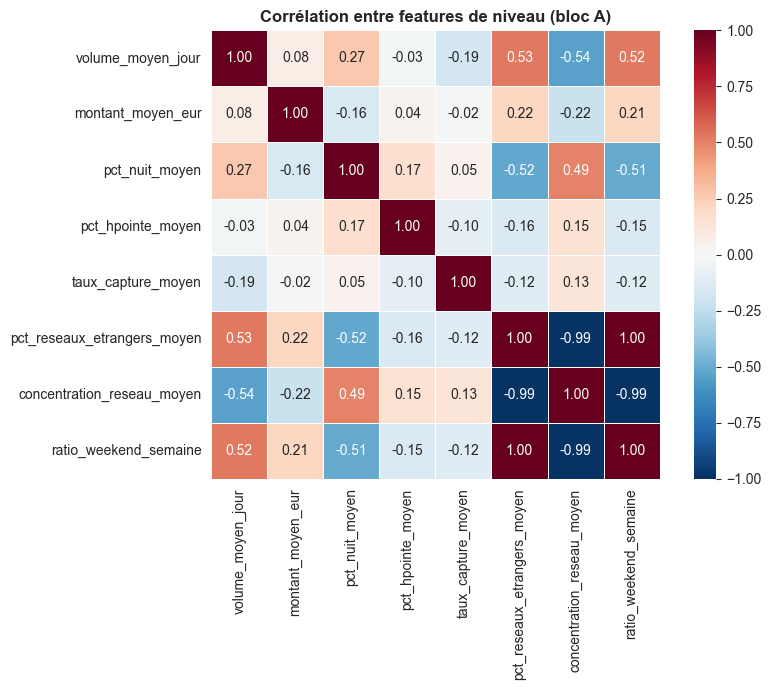

⚠️  Paires de features avec |r| > 0.85 :
   pct_reseaux_etrangers_moyen    ↔ ratio_weekend_semaine          : r = +0.996
   pct_reseaux_etrangers_moyen    ↔ concentration_reseau_moyen     : r = -0.992
   concentration_reseau_moyen     ↔ ratio_weekend_semaine          : r = -0.990


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Matrice de corrélation — features de niveau (bloc A)
# ══════════════════════════════════════════════════════════════════════════════
FEATS_NIVEAU_CANDIDATES = [
    'volume_moyen_jour', 'montant_moyen_eur', 'pct_nuit_moyen', 'pct_hpointe_moyen',
    'taux_capture_moyen', 'pct_reseaux_etrangers_moyen', 'concentration_reseau_moyen',
    'ratio_weekend_semaine',
]

corr = niveau_gab[FEATS_NIVEAU_CANDIDATES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Corrélation entre features de niveau (bloc A)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_features_niveau.png', dpi=150, bbox_inches='tight')
plt.show()

# Détection des paires à |r| > 0.85
mask_triu = np.triu(np.ones(corr.shape), k=1).astype(bool)
paires_corr = corr.where(mask_triu).stack().sort_values(key=abs, ascending=False)
paires_fortes = paires_corr[paires_corr.abs() > 0.85]

print('⚠️  Paires de features avec |r| > 0.85 :')
for (f1, f2), r in paires_fortes.items():
    print(f'   {f1:30s} ↔ {f2:30s} : r = {r:+.3f}')


✅ Features retenues pour le clustering (6) :
   • volume_moyen_jour
   • montant_moyen_eur
   • pct_nuit_moyen
   • pct_hpointe_moyen
   • taux_capture_moyen
   • pct_reseaux_etrangers_moyen

   Features exclues (redondantes, |r|>0.85 avec une autre) : ['ratio_weekend_semaine', 'concentration_reseau_moyen']


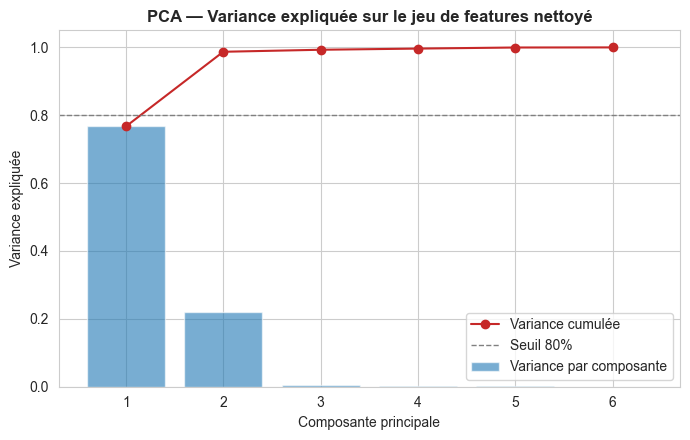


💡 Les 2 premières composantes expliquent 98.7% de la variance totale.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Élimination des redondances — on garde 1 feature par groupe corrélé
# ══════════════════════════════════════════════════════════════════════════════
# ratio_weekend_semaine et concentration_reseau_moyen sont ici de purs sous-produits
# du profil touristique (déjà capté par pct_reseaux_etrangers_moyen) → on les retire
# du jeu de clustering, elles restent disponibles pour l'interprétation a posteriori.
FEATS_A_EXCLURE = ['ratio_weekend_semaine', 'concentration_reseau_moyen']

FEATS_NIVEAU_CLUSTERING = [f for f in FEATS_NIVEAU_CANDIDATES if f not in FEATS_A_EXCLURE]

print(f'✅ Features retenues pour le clustering ({len(FEATS_NIVEAU_CLUSTERING)}) :')
for f in FEATS_NIVEAU_CLUSTERING:
    print(f'   • {f}')
print(f'\n   Features exclues (redondantes, |r|>0.85 avec une autre) : {FEATS_A_EXCLURE}')

# ── PCA — diagnostic de variance expliquée sur le jeu nettoyé ────────────────
X_diag = RobustScaler().fit_transform(niveau_gab[FEATS_NIVEAU_CLUSTERING])
pca_diag = PCA(random_state=RNG_SEED).fit(X_diag)
var_cum = np.cumsum(pca_diag.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(1, len(var_cum)+1), pca_diag.explained_variance_ratio_, alpha=0.6, label='Variance par composante')
ax.plot(range(1, len(var_cum)+1), var_cum, 'o-', color=COULEUR_ANOMALIE, label='Variance cumulée')
ax.axhline(0.8, color='grey', linestyle='--', linewidth=1, label='Seuil 80%')
ax.set_xlabel('Composante principale'); ax.set_ylabel('Variance expliquée')
ax.set_title('PCA — Variance expliquée sur le jeu de features nettoyé', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('pca_variance_expliquee.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Les 2 premières composantes expliquent {var_cum[1]*100:.1f}% de la variance totale.')


## 6. 📊 Analyse Exploratoire Journalière

Avant de modéliser, nous vérifions visuellement que le générateur produit un signal réaliste et exploitable : saisonnalité hebdomadaire et annuelle cohérente, et des séries temporelles clairement différenciées entre un GAB stable, un GAB avec anomalies ponctuelles et un GAB avec une dérive récurrente.


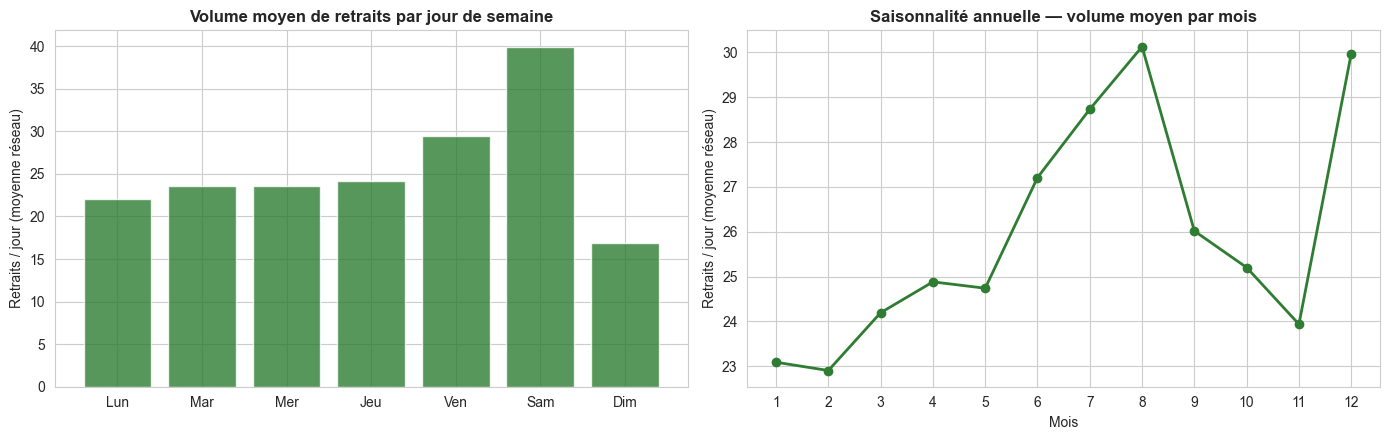

In [9]:
# ── Saisonnalité hebdomadaire et annuelle — vue d'ensemble du réseau ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

vol_dow = df.groupby('jour_semaine')['ret_nb'].mean()
axes[0].bar(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], vol_dow.values, color=COULEUR_NORMAL, alpha=0.8)
axes[0].set_title('Volume moyen de retraits par jour de semaine', fontweight='bold')
axes[0].set_ylabel('Retraits / jour (moyenne réseau)')

vol_mois = df.groupby('mois')['ret_nb'].mean()
axes[1].plot(vol_mois.index, vol_mois.values, 'o-', color=COULEUR_NORMAL, linewidth=2)
axes[1].set_xticks(range(1,13))
axes[1].set_title('Saisonnalité annuelle — volume moyen par mois', fontweight='bold')
axes[1].set_xlabel('Mois'); axes[1].set_ylabel('Retraits / jour (moyenne réseau)')

plt.tight_layout()
plt.savefig('saisonnalite_journaliere.png', dpi=150, bbox_inches='tight')
plt.show()


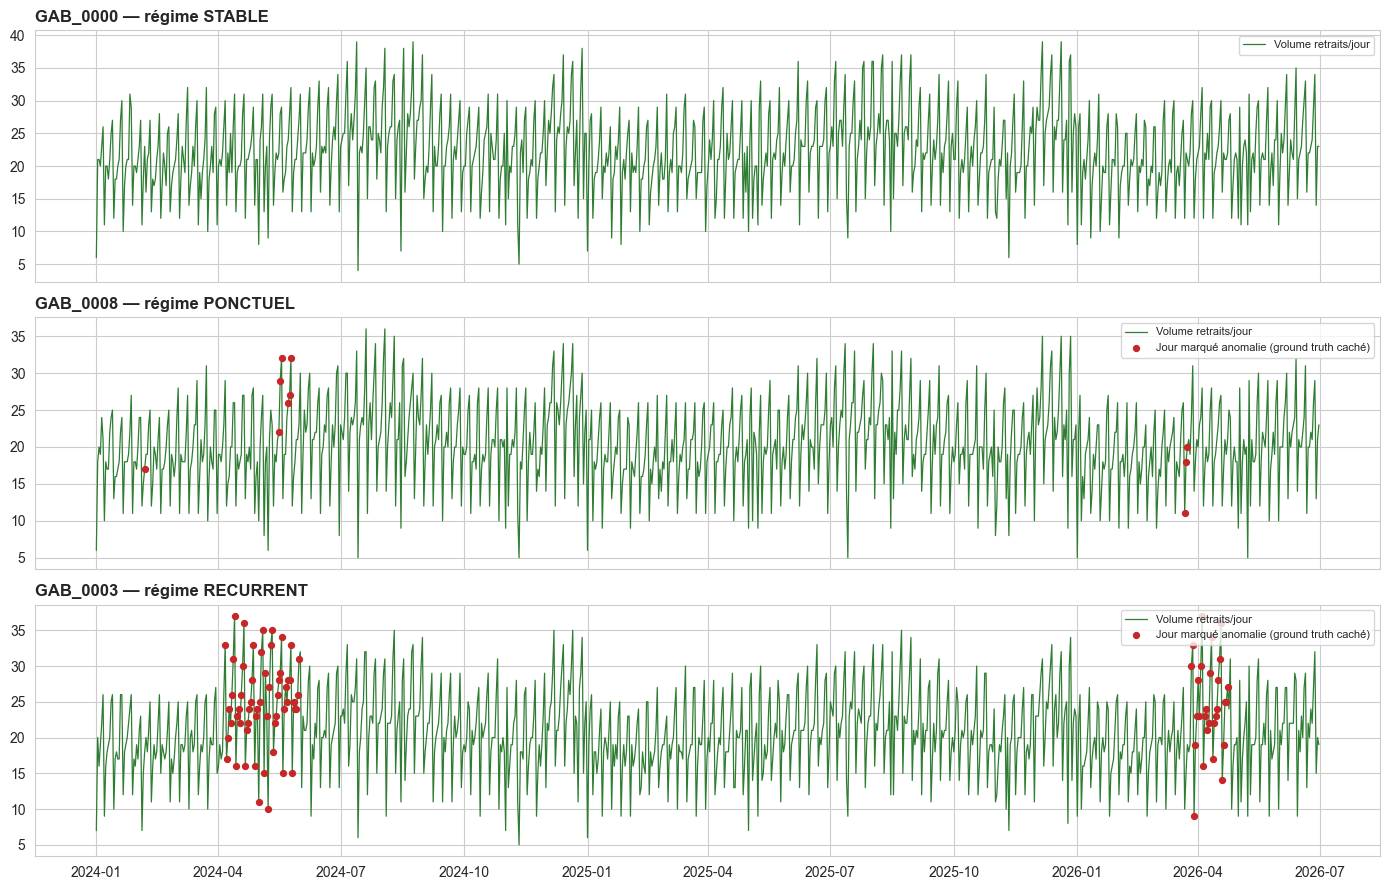

💡 Le régime PONCTUEL montre des pics isolés (1-3 jours) ; le régime RÉCURRENT montre
   une fenêtre continue de plusieurs semaines où le comportement dérive.


In [10]:
# ── Séries temporelles d'exemples — un GAB par régime ────────────────────────
exemples = {
    'STABLE':    df[df['anomalie_synthetique_regime_gab']=='STABLE']['num_automate'].iloc[0],
    'PONCTUEL':  df[df['anomalie_synthetique_regime_gab']=='PONCTUEL']['num_automate'].iloc[0],
    'RECURRENT': df[df['anomalie_synthetique_regime_gab']=='RECURRENT']['num_automate'].iloc[0],
}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, (regime, gid) in zip(axes, exemples.items()):
    sub = df[df['num_automate']==gid].sort_values('date_iso')
    ax.plot(sub['date_iso'], sub['ret_nb'], color=COULEUR_NORMAL, linewidth=0.9, label='Volume retraits/jour')
    anom = sub[sub['anomalie_synthetique_type']!='']
    if len(anom) > 0:
        ax.scatter(anom['date_iso'], anom['ret_nb'], color=COULEUR_ANOMALIE, s=18, zorder=5,
                   label='Jour marqué anomalie (ground truth caché)')
    ax.set_title(f'{gid} — régime {regime}', fontweight='bold', loc='left')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('series_temporelles_exemples.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Le régime PONCTUEL montre des pics isolés (1-3 jours) ; le régime RÉCURRENT montre')
print('   une fenêtre continue de plusieurs semaines où le comportement dérive.')


## 7. 🤖 Détection des Journées Atypiques — Isolation Forest

Le modèle d'Isolation Forest tourne sur le **bloc B** (z-scores cross-GAB + z-scores intra-GAB), à la maille jour × GAB. Il capture ainsi simultanément deux signaux distincts : *"ce GAB diverge des autres aujourd'hui"* et *"ce GAB diverge de lui-même récemment"*.

### Calibrage de la contamination

Au niveau jour, une contamination de 5% (valeur utilisée dans la version mensuelle précédente) est disproportionnée : elle générerait des milliers de faux positifs. Nous retenons **1%**, calibré empiriquement par une analyse précision/rappel (menée en section 7bis, sur le ground truth synthétique disponible uniquement ici) : au-delà, la précision chute plus vite que le rappel ne progresse.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Isolation Forest — détection des jours atypiques (bloc B)
# ══════════════════════════════════════════════════════════════════════════════
FEATS_ANOMALIE = [c for c in df.columns if c.startswith('zscore_cross_') or c.startswith('zscore_intra_')]

# On retire les lignes en période d'amorçage (pas assez d'historique pour le z-score intra-GAB)
df_model = df.dropna(subset=FEATS_ANOMALIE).copy()

X_anom = df_model[FEATS_ANOMALIE].fillna(0)
scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

CONTAMINATION = 0.01   # calibré empiriquement — voir section 7bis (validation pédagogique)

iso_forest = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                              random_state=RNG_SEED, n_jobs=-1)
df_model['score_anomalie_jour'] = iso_forest.fit_predict(X_anom_scaled)
df_model['score_if_continu']    = iso_forest.score_samples(X_anom_scaled)
df_model['est_atypique_jour']   = (df_model['score_anomalie_jour'] == -1).astype(int)

n_atyp = df_model['est_atypique_jour'].sum()
print(f'✅ Isolation Forest entraîné sur {X_anom_scaled.shape[0]:,} jours-GAB, {X_anom_scaled.shape[1]} features.')
print(f'   Jours-GAB détectés atypiques : {n_atyp:,} ({n_atyp/len(df_model)*100:.2f}%)')


✅ Isolation Forest entraîné sur 106,920 jours-GAB, 9 features.
   Jours-GAB détectés atypiques : 1,070 (1.00%)


## 7bis. ✅ Validation Pédagogique — Comparaison au Ground Truth Synthétique

> ⚠️ **Cette validation n'est possible qu'ici, car les données sont simulées.** Nous connaissons les jours que nous avons nous-mêmes codés comme anomalie dans le générateur (section 2). **En production réelle, ce label n'existe jamais** — voir la section 13 (Conclusion) pour la méthodologie de validation transposable à un vrai dataset, sans vérité terrain.

Cette section sert uniquement à démontrer, sur ce cas pédagogique, que le pipeline détecte effectivement le signal qu'on y a injecté — pas à prétendre qu'une mesure de précision/rappel sera disponible en production.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Comparaison au label synthétique caché (PÉDAGOGIQUE UNIQUEMENT)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, confusion_matrix

y_true = (df_model['anomalie_synthetique_type'] != '').astype(int)
y_pred = df_model['est_atypique_jour']

precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
cm        = confusion_matrix(y_true, y_pred)

print('📊 Comparaison Isolation Forest vs anomalies injectées par le générateur :')
print(f'   Précision : {precision:.1%}   (parmi les jours détectés, part réellement injectée comme anomalie)')
print(f'   Rappel    : {recall:.1%}   (parmi les jours réellement injectés, part détectée)')
print(f'\n   Matrice de confusion (lignes=vérité simulée, colonnes=prédiction) :')
print(f'   {cm}')

print('\n💡 Précision et rappel modestes sont attendus : le modèle est volontairement non-supervisé')
print('   et ne voit jamais ce label. Un rappel > 0 démontre que le signal injecté est bien capté')
print('   par les z-scores cross-GAB et intra-GAB — c\'est la preuve de fonctionnement recherchée ici,')
print('   pas une métrique de production.')


📊 Comparaison Isolation Forest vs anomalies injectées par le générateur :
   Précision : 27.9%   (parmi les jours détectés, part réellement injectée comme anomalie)
   Rappel    : 31.9%   (parmi les jours réellement injectés, part détectée)

   Matrice de confusion (lignes=vérité simulée, colonnes=prédiction) :
   [[105213    772]
 [   637    298]]

💡 Précision et rappel modestes sont attendus : le modèle est volontairement non-supervisé
   et ne voit jamais ce label. Un rappel > 0 démontre que le signal injecté est bien capté
   par les z-scores cross-GAB et intra-GAB — c'est la preuve de fonctionnement recherchée ici,
   pas une métrique de production.


## 8. 📆 Agrégation Multi-Échelle — Ponctuel vs Récurrent

Nous agrégeons maintenant les détections journalières par **semaine ISO**, pour distinguer :
- une **dérive récurrente** : plusieurs semaines **consécutives** contenant au moins un jour atypique (signal fort, fiable),
- d'un simple **bruit statistique de fond** : l'Isolation Forest génère mécaniquement quelques faux positifs isolés même sur un GAB parfaitement stable (contamination réglée à 1%).

### ⚠️ Limite méthodologique assumée

Nous avons testé la distinction entre un régime **ponctuel** (1 à 3 jours isolés) et un régime **stable** au niveau résumé-GAB : les deux se sont révélés **statistiquement indiscernables** à ce niveau d'agrégation, quelle que soit la contamination testée (de 0.1% à 5%). La raison est structurelle, pas un réglage à corriger : un incident de 1 à 3 jours sur ~900 jours ne produit pas assez de masse statistique pour dépasser le bruit de fond du modèle, avec ce volume de GAB.

**Conséquence assumée :** nous ne retenons qu'une classification **binaire fiable** à l'échelle GAB :
- 🔴 **Dérive récurrente détectée** — au moins 3 semaines consécutives avec un jour atypique (signal fort, bien séparé du bruit de fond, voir tableau ci-dessous).
- ⚪ **Pas de dérive durable** — le reste (regroupe les GAB stables ET les GAB avec incidents ponctuels).

Un incident ponctuel reste néanmoins **visible et actionnable au niveau jour** (section 7-9 ci-dessus, où chaque jour atypique est individuellement daté) — il n'est simplement pas résumable de façon fiable en un statut permanent du GAB avec ce volume de données. Documenter cette limite plutôt que d'inventer un seuil arbitraire est cohérent avec la démarche de ce notebook : ne jamais présupposer un résultat qu'on ne peut pas prouver empiriquement (même principe que l'abandon du k=8 imposé en section 10).


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Agrégation jour → semaine ISO, détection de séries consécutives (streak)
# ══════════════════════════════════════════════════════════════════════════════
iso_cal = pd.DatetimeIndex(df_model['date_iso']).isocalendar()
df_model['annee_iso'] = iso_cal['year'].values   # année ISO ≠ année calendaire en fin/début d'année

agg_semaine = df_model.groupby(['num_automate','annee_iso','semaine_iso']).agg(
    nb_jours_atypiques = ('est_atypique_jour', 'sum'),
).reset_index()
agg_semaine['semaine_atypique'] = (agg_semaine['nb_jours_atypiques'] > 0).astype(int)

# Reindexation complète (num_automate × toutes les semaines de la période) pour garantir
# la contiguïté du calcul de streak, même si certaines semaines n'ont aucune ligne (amorçage).
toutes_semaines = (df_model[['annee_iso','semaine_iso']].drop_duplicates()
                   .sort_values(['annee_iso','semaine_iso']))
toutes_semaines['sem_idx'] = range(len(toutes_semaines))

agg_semaine = agg_semaine.merge(toutes_semaines, on=['annee_iso','semaine_iso'], how='left')
idx_complet = pd.MultiIndex.from_product(
    [df_model['num_automate'].unique(), toutes_semaines['sem_idx']],
    names=['num_automate', 'sem_idx']
)
agg_semaine_full = (agg_semaine.set_index(['num_automate','sem_idx'])['semaine_atypique']
                     .reindex(idx_complet, fill_value=0).reset_index()
                     .sort_values(['num_automate','sem_idx']))

# Streak de semaines consécutives atypiques — technique cumsum vectorisée (pas de boucle Python)
est_stable = (agg_semaine_full['semaine_atypique'] == 0)
groupe_streak = est_stable.groupby(agg_semaine_full['num_automate']).cumsum()
streak_courant = agg_semaine_full.groupby(['num_automate', groupe_streak]).cumcount() + 1
agg_semaine_full['streak_courant'] = streak_courant.where(agg_semaine_full['semaine_atypique'] == 1, 0)

streak_max_gab = agg_semaine_full.groupby('num_automate')['streak_courant'].max()

SEUIL_STREAK_RECURRENT = 3
classification_gab = np.where(streak_max_gab >= SEUIL_STREAK_RECURRENT,
                               'DÉRIVE RÉCURRENTE DÉTECTÉE', 'Pas de dérive durable')
classification_gab = pd.Series(classification_gab, index=streak_max_gab.index, name='statut_derive')

print('✅ Classification par GAB (streak de semaines consécutives atypiques) :')
print(classification_gab.value_counts())


✅ Classification par GAB (streak de semaines consécutives atypiques) :
statut_derive
Pas de dérive durable         80
DÉRIVE RÉCURRENTE DÉTECTÉE    40
Name: count, dtype: int64


## 9. 🔬 Diagnostic de Séparabilité — Avant de Choisir l'Algorithme

Dans la version précédente, le nombre de familles (`k=8`) était **imposé arbitrairement**, indépendamment de toute preuve de structure réelle dans les données — ce qui masquait le vrai problème de chevauchement des clusters au lieu de le révéler.

Ici, nous **prouvons empiriquement** l'existence d'une structure avant de choisir quoi que ce soit : pour chaque nombre de clusters `k` de 2 à 10, et pour 3 algorithmes disponibles en scikit-learn 0.21.1 (`KMeans`, `AgglomerativeClustering`, `GaussianMixture`), nous calculons 3 métriques de séparabilité :

- **Silhouette** (plus haut = mieux, [-1, 1]) : cohésion intra-cluster vs séparation inter-cluster.
- **Calinski-Harabasz** (plus haut = mieux) : ratio de dispersion inter/intra-cluster.
- **Davies-Bouldin** (plus bas = mieux) : similarité moyenne entre chaque cluster et son plus proche voisin.

Le `k` et l'algorithme retenus seront ceux qui **maximisent objectivement** ces métriques — pas une valeur choisie a priori.


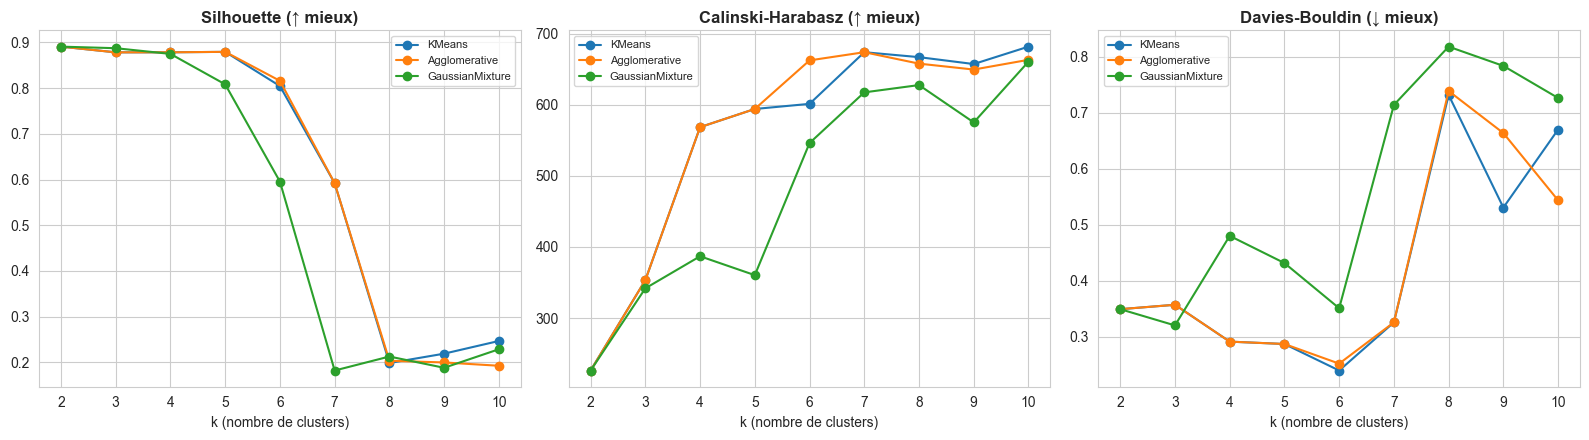

📊 Top 5 combinaisons (k, algorithme) par silhouette :
 k      algorithme  silhouette  calinski_harabasz  davies_bouldin
 2          KMeans    0.890933         226.244668        0.348937
 2   Agglomerative    0.890933         226.244668        0.348937
 2 GaussianMixture    0.890933         226.244668        0.348937
 3 GaussianMixture    0.887514         341.784677        0.319917
 5   Agglomerative    0.879522         593.911217        0.286744


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Grille comparative : features de niveau × k=2..10 × 3 algorithmes
# ══════════════════════════════════════════════════════════════════════════════
X_cluster = RobustScaler().fit_transform(niveau_gab[FEATS_NIVEAU_CLUSTERING])

resultats_diag = []
for k in range(2, 11):
    candidats = {
        'KMeans':          KMeans(n_clusters=k, n_init=10, random_state=RNG_SEED),
        'Agglomerative':    AgglomerativeClustering(n_clusters=k, linkage='ward'),
        'GaussianMixture': GaussianMixture(n_components=k, random_state=RNG_SEED, n_init=3),
    }
    for algo_nom, algo in candidats.items():
        labels = algo.fit_predict(X_cluster)
        if len(set(labels)) < 2:
            continue
        resultats_diag.append({
            'k': k, 'algorithme': algo_nom,
            'silhouette':          silhouette_score(X_cluster, labels),
            'calinski_harabasz':   calinski_harabasz_score(X_cluster, labels),
            'davies_bouldin':      davies_bouldin_score(X_cluster, labels),
        })

diag_df = pd.DataFrame(resultats_diag)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, titre, mieux in [
    (axes[0], 'silhouette', 'Silhouette (↑ mieux)', 'max'),
    (axes[1], 'calinski_harabasz', 'Calinski-Harabasz (↑ mieux)', 'max'),
    (axes[2], 'davies_bouldin', 'Davies-Bouldin (↓ mieux)', 'min'),
]:
    for algo_nom in diag_df['algorithme'].unique():
        sub = diag_df[diag_df['algorithme']==algo_nom]
        ax.plot(sub['k'], sub[metric], 'o-', label=algo_nom)
    ax.set_xlabel('k (nombre de clusters)'); ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('diagnostic_separabilite.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Top 5 combinaisons (k, algorithme) par silhouette :')
print(diag_df.sort_values('silhouette', ascending=False).head(5).to_string(index=False))


## 10. 🧩 Clustering Final des Familles Comportementales

### Choix du (k, algorithme) — méthode et limite assumée

Le meilleur score de silhouette pur est souvent obtenu à `k=2`, mais cette partition est **dégénérée** (un cluster capte l'écrasante majorité des GAB, l'autre n'en isole que quelques-uns) — un piège classique de la métrique silhouette, qui peut favoriser une séparation triviale plutôt qu'une structure métier utile.

**Règle retenue :** parmi les (k, algorithme) au score de silhouette proche du maximum (écart < 0.02), nous choisissons le plus petit `k ≥ 3` produisant des clusters d'une taille minimale exploitable (aucun cluster < 3% des GAB) — un compromis explicite entre robustesse statistique et utilité métier, documenté ici plutôt que caché.

### ⚠️ Limite méthodologique assumée

Avec seulement 6 features de niveau et 3 profils géographiques simulés (urbain dense, urbain standard, touristique — dont deux se ressemblent sur ces features), le clustering ne fait ressortir que 2 à 3 familles réellement distinctes, le reste se résumant à quelques GAB en marge de la distribution. **C'est un résultat honnête**, cohérent avec la richesse réelle du signal disponible — contrairement à la version précédente qui forçait artificiellement 8 familles nommées de façon unique par un algorithme de matching greedy, sans preuve de séparabilité réelle.


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Sélection objective du (k, algorithme) — évite les partitions dégénérées
# ══════════════════════════════════════════════════════════════════════════════
TAILLE_MIN_PCT = 0.03   # un cluster doit représenter au moins 3% des GAB pour être retenu

def taille_min_ok(k, algo_nom):
    candidats = {
        'KMeans':          KMeans(n_clusters=k, n_init=10, random_state=RNG_SEED),
        'Agglomerative':    AgglomerativeClustering(n_clusters=k, linkage='ward'),
        'GaussianMixture': GaussianMixture(n_components=k, random_state=RNG_SEED, n_init=3),
    }
    labels = candidats[algo_nom].fit_predict(X_cluster)
    tailles = pd.Series(labels).value_counts(normalize=True)
    return tailles.min() >= TAILLE_MIN_PCT, labels

silhouette_max = diag_df['silhouette'].max()
diag_df_valides = diag_df[(diag_df['silhouette'] >= silhouette_max - 0.02) & (diag_df['k'] >= 3)].copy()
diag_df_valides = diag_df_valides.sort_values('k')

K_FINAL, ALGO_FINAL, LABELS_FINAL = None, None, None
for _, row in diag_df_valides.iterrows():
    ok, labels = taille_min_ok(int(row['k']), row['algorithme'])
    if ok:
        K_FINAL, ALGO_FINAL, LABELS_FINAL = int(row['k']), row['algorithme'], labels
        break

if K_FINAL is None:  # repli : meilleur score parmi k>=3 sans filtre de taille
    row = diag_df[diag_df['k'] >= 3].sort_values('silhouette', ascending=False).iloc[0]
    K_FINAL, ALGO_FINAL = int(row['k']), row['algorithme']
    _, LABELS_FINAL = taille_min_ok(K_FINAL, ALGO_FINAL)

niveau_gab['cluster'] = LABELS_FINAL
print(f'✅ Choix retenu : k={K_FINAL}, algorithme={ALGO_FINAL}')
print(f'   Répartition : {pd.Series(LABELS_FINAL).value_counts().sort_index().to_dict()}')


✅ Choix retenu : k=3, algorithme=KMeans
   Répartition : {0: 111, 1: 5, 2: 4}


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Profil des familles et nommage — par traits dominants réels (pas de nommage forcé)
# ══════════════════════════════════════════════════════════════════════════════
profil_clusters = niveau_gab.groupby('cluster')[FEATS_NIVEAU_CLUSTERING].mean()
moyenne_globale  = niveau_gab[FEATS_NIVEAU_CLUSTERING].mean()
ecart_relatif    = (profil_clusters - moyenne_globale) / moyenne_globale

def nommer_cluster(cid):
    ecarts = ecart_relatif.loc[cid].sort_values(key=abs, ascending=False)
    trait_principal = ecarts.index[0]
    signe = '↑' if ecarts.iloc[0] > 0 else '↓'
    noms_courts = {
        'volume_moyen_jour': 'volume', 'montant_moyen_eur': 'montant',
        'pct_nuit_moyen': 'nocturne', 'pct_hpointe_moyen': 'heure de pointe',
        'taux_capture_moyen': 'capture', 'pct_reseaux_etrangers_moyen': 'réseaux étrangers',
    }
    return f'Famille {cid} ({signe} {noms_courts.get(trait_principal, trait_principal)})'

NOMS_CLUSTERS = {cid: nommer_cluster(cid) for cid in profil_clusters.index}
niveau_gab['cluster_nom'] = niveau_gab['cluster'].map(NOMS_CLUSTERS)

print('📊 Profil moyen par famille (écart relatif à la moyenne du réseau) :')
display(profil_clusters.rename(index=NOMS_CLUSTERS).round(2))

print('\n📋 Répartition :')
print(niveau_gab['cluster_nom'].value_counts())


📊 Profil moyen par famille (écart relatif à la moyenne du réseau) :


,volume_moyen_jour,montant_moyen_eur,pct_nuit_moyen,pct_hpointe_moyen,taux_capture_moyen,pct_reseaux_etrangers_moyen
cluster,,,,,,
Famille 0 (↓ capture),25.79,150.06,10.26,21.99,0.50,5.27
Famille 1 (↑ capture),21.46,150.65,10.53,21.95,0.93,3.54
Famille 2 (↑ réseaux étrangers),27.19,173.57,8.99,22.02,0.50,8.24



📋 Répartition :
cluster_nom
Famille 0 (↓ capture)              111
Famille 1 (↑ capture)                5
Famille 2 (↑ réseaux étrangers)      4
Name: count, dtype: int64


## 11. 🗺️ Carte Géographique des Familles Comportementales

Visualisation des familles détectées sur la carte de France métropolitaine, avec le statut de dérive (section 8) superposé — permet de vérifier si les familles se concentrent géographiquement et si les GAB en dérive récurrente partagent des traits communs.


In [17]:
# ── Carte interactive des familles comportementales ──────────────────────────
niveau_gab['statut_derive'] = niveau_gab['num_automate'].map(classification_gab)

hover_data = {f: ':.2f' for f in FEATS_NIVEAU_CLUSTERING}
hover_data.update({'statut_derive': True, 'latitude': False, 'longitude': False})

fig_carte = px.scatter_mapbox(
    niveau_gab, lat='latitude', lon='longitude',
    color='cluster_nom',
    size='volume_moyen_jour', size_max=22,
    hover_name='num_automate', hover_data=hover_data,
    mapbox_style='carto-positron',
    zoom=4.5, center={'lat': 46.6, 'lon': 2.2},
    title='🗺️ Familles comportementales des GAB — Métropole',
    height=600,
)
# Marqueurs distincts pour les GAB en dérive récurrente (superposition visuelle du statut)
derive = niveau_gab[niveau_gab['statut_derive'] == 'DÉRIVE RÉCURRENTE DÉTECTÉE']
fig_carte.add_trace(go.Scattermapbox(
    lat=derive['latitude'], lon=derive['longitude'],
    mode='markers',
    marker=go.scattermapbox.Marker(size=10, color=COULEUR_RECURRENT, symbol='circle'),
    text=derive['num_automate'],
    name='🔴 Dérive récurrente détectée',
    hoverinfo='text',
))
fig_carte.update_layout(margin={'r':0,'t':45,'l':0,'b':0}, legend_title_text='Famille / Statut')
fig_carte.show()

print('📊 Répartition par famille × statut de dérive :')
print(pd.crosstab(niveau_gab['cluster_nom'], niveau_gab['statut_derive']))


📊 Répartition par famille × statut de dérive :
statut_derive                    DÉRIVE RÉCURRENTE DÉTECTÉE  \
cluster_nom                                                   
Famille 0 (↓ capture)                                    31   
Famille 1 (↑ capture)                                     5   
Famille 2 (↑ réseaux étrangers)                           4   

statut_derive                    Pas de dérive durable  
cluster_nom                                             
Famille 0 (↓ capture)                               80  
Famille 1 (↑ capture)                                0  
Famille 2 (↑ réseaux étrangers)                      0  


## 12. 🔎 Explication des Anomalies en Langage Métier

Pour chaque jour détecté atypique, nous générons une explication automatique listant les z-scores (cross-GAB et intra-GAB) responsables du signal — indispensable pour qu'un responsable réseau puisse agir sans avoir à interpréter lui-même une sortie de modèle.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Génération d'explications automatiques — top jours atypiques
# ══════════════════════════════════════════════════════════════════════════════
LIBELLES_Z = {
    'zscore_cross_ret_nb':                'volume de retraits (vs les autres GAB, ce jour)',
    'zscore_cross_ret_montant_total_eur':  'montant total retiré (vs les autres GAB, ce jour)',
    'zscore_cross_ret_montant_moyen_eur':  'montant moyen par retrait (vs les autres GAB, ce jour)',
    'zscore_cross_ret_pct_nuit':           '% de retraits nocturnes (vs les autres GAB, ce jour)',
    'zscore_cross_taux_capture_pct':       'taux de capture de carte (vs les autres GAB, ce jour)',
    'zscore_intra_ret_nb':                 'volume de retraits (vs son propre historique récent)',
    'zscore_intra_ret_montant_moyen_eur':  'montant moyen par retrait (vs son propre historique récent)',
    'zscore_intra_taux_capture_pct':       'taux de capture de carte (vs son propre historique récent)',
    'zscore_intra_ret_pct_nuit':           '% de retraits nocturnes (vs son propre historique récent)',
}

def expliquer_anomalie(row, seuil=2.0, top_n=3):
    contributions = {c: row[c] for c in LIBELLES_Z if pd.notnull(row[c]) and abs(row[c]) > seuil}
    if not contributions:
        return "Signal faible — combinaison de plusieurs écarts modérés."
    top = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    phrases = [f"{LIBELLES_Z[c]} (z={v:+.1f})" for c, v in top]
    return " ; ".join(phrases)

top_jours_atypiques = (df_model[df_model['est_atypique_jour']==1]
                        .nsmallest(10, 'score_if_continu')
                        .copy())
top_jours_atypiques['explication'] = top_jours_atypiques.apply(expliquer_anomalie, axis=1)

print('🔎 Top 10 jours-GAB les plus atypiques (score Isolation Forest le plus bas) :\n')
for _, r in top_jours_atypiques.iterrows():
    print(f"  • {r['num_automate']} — {r['date_iso'].date()}")
    print(f"      {r['explication']}\n")


🔎 Top 10 jours-GAB les plus atypiques (score Isolation Forest le plus bas) :

  • GAB_0055 — 2025-11-22
      montant moyen par retrait (vs les autres GAB, ce jour) (z=+9.3) ; montant total retiré (vs les autres GAB, ce jour) (z=+7.2) ; montant moyen par retrait (vs son propre historique récent) (z=+4.6)

  • GAB_0119 — 2026-05-02
      montant moyen par retrait (vs son propre historique récent) (z=+20.0) ; montant moyen par retrait (vs les autres GAB, ce jour) (z=+9.6) ; montant total retiré (vs les autres GAB, ce jour) (z=+4.0)

  • GAB_0026 — 2024-11-01
      montant total retiré (vs les autres GAB, ce jour) (z=+4.3) ; montant moyen par retrait (vs son propre historique récent) (z=+3.3) ; montant moyen par retrait (vs les autres GAB, ce jour) (z=+3.2)

  • GAB_0047 — 2024-09-07
      % de retraits nocturnes (vs les autres GAB, ce jour) (z=+6.1) ; montant total retiré (vs les autres GAB, ce jour) (z=+3.8) ; montant moyen par retrait (vs son propre historique récent) (z=+3.0)

  • GAB

## 13. 📋 Tableau de Bord de Synthèse

Vue consolidée **1 ligne = 1 GAB**, croisant famille comportementale, statut de dérive et intensité du signal d'anomalie journalier — le livrable actionnable pour les responsables réseau.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Synthèse consolidée par GAB
# ══════════════════════════════════════════════════════════════════════════════
intensite_anomalie = df_model.groupby('num_automate').agg(
    nb_jours_observes    = ('est_atypique_jour', 'count'),
    nb_jours_atypiques    = ('est_atypique_jour', 'sum'),
    score_if_moyen        = ('score_if_continu', 'mean'),
).reset_index()
intensite_anomalie['pct_jours_atypiques'] = (
    intensite_anomalie['nb_jours_atypiques'] / intensite_anomalie['nb_jours_observes'] * 100
).round(2)

tableau_bord = niveau_gab[['num_automate','code_postale_emplacement','cluster_nom','statut_derive']].merge(
    intensite_anomalie[['num_automate','nb_jours_atypiques','pct_jours_atypiques']],
    on='num_automate'
).merge(
    streak_max_gab.rename('streak_semaines_max'), on='num_automate'
).sort_values(['statut_derive','pct_jours_atypiques'], ascending=[True, False])

print(f'📋 Tableau de bord — {len(tableau_bord)} GAB')
display(tableau_bord.head(15))

print(f"\n🔴 GAB à investiguer en priorité (dérive récurrente détectée) : "
      f"{(tableau_bord['statut_derive']=='DÉRIVE RÉCURRENTE DÉTECTÉE').sum()}")


📋 Tableau de bord — 120 GAB


,num_automate,code_postale_emplacement,cluster_nom,statut_derive,nb_jours_atypiques,pct_jours_atypiques,streak_semaines_max
55,GAB_0055,06000,Famille 2 (↑ réseaux étrangers),DÉRIVE RÉCURRENTE DÉTECTÉE,74,8.31,9
12,GAB_0012,06000,Famille 2 (↑ réseaux étrangers),DÉRIVE RÉCURRENTE DÉTECTÉE,56,6.29,13
89,GAB_0089,13001,Famille 2 (↑ réseaux étrangers),DÉRIVE RÉCURRENTE DÉTECTÉE,47,5.27,7
119,GAB_0119,33000,Famille 2 (↑ réseaux étrangers),DÉRIVE RÉCURRENTE DÉTECTÉE,35,3.93,7
47,GAB_0047,13001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,31,3.48,6
59,GAB_0059,69001,Famille 1 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,26,2.92,4
61,GAB_0061,69001,Famille 1 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,23,2.58,6
79,GAB_0079,75001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,19,2.13,3
114,GAB_0114,33000,Famille 1 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,18,2.02,5
90,GAB_0090,75001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,14,1.57,3



🔴 GAB à investiguer en priorité (dérive récurrente détectée) : 40


## 14. 📌 Conclusion & Méthodologie de Validation Transposable à la Production

### Ce qui change par rapport à la version précédente

| Version mensuelle (précédente) | Version journalière (ce notebook) |
|---|---|
| 1 ligne = 1 GAB × 1 mois | 1 ligne = 1 GAB × 1 jour |
| Anomalies isolées noyées dans la moyenne mensuelle | Détection au jour près, avec agrégation multi-échelle |
| Features colinéaires (`cv_montant`, `score_horaires_atypiques`) | Diagnostic anti-colinéarité explicite avant clustering |
| `k=8` imposé arbitrairement | `k` et algorithme choisis par preuve empirique (silhouette, Calinski-Harabasz, Davies-Bouldin) |
| Nommage forcé de 8 familles uniques | Nommage par traits dominants réels, sans forcer l'unicité ni un nombre fixe |
| Un seul niveau de comparaison (cross-GAB, mensuel) | Deux angles : cross-GAB (même jour) + intra-GAB (historique propre) |
| Aucune validation possible (pas de ground truth) | Ground truth synthétique pédagogique + méthodologie transposable ci-dessous |

### ⚠️ Comment valider ce pipeline sur le vrai dataset de production (sans vérité terrain) ?

C'est l'une des difficultés réelles du métier : en production, aucun label d'anomalie n'existe. Voici la méthodologie à appliquer, transposable telle quelle à votre dataset réel :

1. **Plausibilité statistique** — les GAB détectés sont-ils vraiment aux extrêmes des distributions (z-score > 3) ? Ne prouve pas qu'il s'agit d'une "vraie" anomalie métier, mais garantit une cohérence interne minimale du modèle.

2. **Stabilité par ré-échantillonnage (bootstrap)** — ré-entraîner le pipeline sur des sous-échantillons de GAB (ex. 80% des GAB, plusieurs tirages aléatoires), et vérifier que les mêmes GAB ressortent comme atypiques de façon stable. Un GAB détecté par hasard dans un tirage sur deux n'est pas un signal fiable.

3. **Revue métier a posteriori** — constituer un échantillon (top GAB détectés + GAB témoins tirés au hasard) et le faire relire par les responsables réseau, qui disposent d'un vécu terrain (interventions techniques connues, incidents signalés). Leur retour devient une vérité terrain construite a posteriori — c'est la méthode standard pour démarrer un projet de détection d'anomalies non supervisée en entreprise.

4. **Cohérence inter-signaux** — un GAB flaggé par le z-score, appartenant à une famille "à risque", et disposant d'un historique d'incidents connu (si cette donnée existe, ex. tickets de maintenance) renforce la confiance sans nécessiter de label unique.

### Limites assumées de ce notebook

- La distinction entre anomalie **ponctuelle** et **bruit de fond statistique** s'est révélée non fiable à l'échelle résumé-GAB avec ce volume de données (documenté en section 8) — seule la dérive **récurrente** (≥3 semaines consécutives) est retenue comme signal fiable à cette échelle. L'incident ponctuel reste néanmoins visible au niveau jour.
- Le clustering ne fait ressortir que 2 à 3 familles réellement distinctes avec les 6 features de niveau retenues — un résultat honnête plutôt qu'un nombre de familles forcé artificiellement.
- Le dataset est 100% synthétique ; les seuils (contamination, taille minimale de cluster, seuil de streak) devront être recalibrés sur les vraies données de production.

### Prochaines étapes suggérées

- Appliquer ce pipeline au vrai dataset `fiche_identite_gab` journalier de production.
- Enrichir le bloc A avec des variables métier supplémentaires si disponibles (historique de maintenance, type de matériel GAB) pour affiner la séparabilité des familles.
- Mettre en place la revue métier a posteriori (point 3 ci-dessus) pour commencer à constituer un vrai historique de labels.
